## 1 - **Importação das bibliotecas**:



In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter


---
## 2 - **Carregamento dos dados**:

In [188]:
id_arquivo = "1PDxb4XZVuq790M2gEKHbNODajuUKVwZj"

url = f"https://drive.google.com/uc?export=download&id={id_arquivo}"

dados_originais = pd.read_csv(url, encoding="latin1")



---
## 3 - **Visualização dos dados brutos:**


In [189]:
dados_originais.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164



## 3.1 - **Tamanho da base de dados**:

In [190]:
dados_originais.shape

(9994, 21)

## 3.2 - **Tipos de dados e outras informações:**

In [191]:
dados_originais.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## 3.3 - **Estatísticas gerais:**

Nota: Com essa visualização inicial é possivel começar o tratamento dos dados para uma compreensão mais confiavel das informações.

In [192]:
dados_originais.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000




---


## 4 - **Tratamento dos dados**:

Inicio copiando os dados originais para não causar alterações e traduzindo as colunas para facilitar visualizações futuras.

In [193]:
dados = dados_originais.copy()

In [194]:
dados = dados.rename(columns={
    "Row ID": "id_linha",
    "Order ID": "id_pedido",
    "Order Date": "data_pedido",
    "Ship Date": "data_envio",
    "Ship Mode": "modo_envio",
    "Customer ID": "id_cliente",
    "Customer Name": "nome_cliente",
    "Segment": "segmento",
    "Country": "pais",
    "City": "cidade",
    "State": "estado",
    "Postal Code": "cep",
    "Region": "regiao",
    "Product ID": "id_produto",
    "Category": "categoria",
    "Sub-Category": "subcategoria",
    "Product Name": "nome_produto",
    "Sales": "vendas",
    "Quantity": "quantidade",
    "Discount": "desconto",
    "Profit": "lucro"
})


## 4.1 - **Verificação de duplicações e valores nulos:**

Valores duplicados:

In [195]:
duplicados = dados.duplicated()
print(f"Linhas duplicadas: {duplicados.sum()}")

Linhas duplicadas: 0


Valores nulos:

In [196]:
nulos = dados.isnull().sum()
print(f"Valores nulos: \n{nulos}")

Valores nulos: 
id_linha        0
id_pedido       0
data_pedido     0
data_envio      0
modo_envio      0
id_cliente      0
nome_cliente    0
segmento        0
pais            0
cidade          0
estado          0
cep             0
regiao          0
id_produto      0
categoria       0
subcategoria    0
nome_produto    0
vendas          0
quantidade      0
desconto        0
lucro           0
dtype: int64


É possivel visualizar que nenhum valor nulo ou duplicado foi encontrado então não é necessária a remoção de qualquer valor que possa causar erros durante a análise dos dados.

## 4.2 - **Conversão de valores:**

Alterando valores object para datetime:

In [197]:
dados["data_pedido"] = pd.to_datetime(dados["data_pedido"], format="%m/%d/%Y", errors="coerce")
dados["data_envio"] = pd.to_datetime(dados["data_envio"], format="%m/%d/%Y", errors="coerce")

Visualizando se os tipos foram alterados corretamente:

In [198]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_linha      9994 non-null   int64         
 1   id_pedido     9994 non-null   object        
 2   data_pedido   9994 non-null   datetime64[ns]
 3   data_envio    9994 non-null   datetime64[ns]
 4   modo_envio    9994 non-null   object        
 5   id_cliente    9994 non-null   object        
 6   nome_cliente  9994 non-null   object        
 7   segmento      9994 non-null   object        
 8   pais          9994 non-null   object        
 9   cidade        9994 non-null   object        
 10  estado        9994 non-null   object        
 11  cep           9994 non-null   int64         
 12  regiao        9994 non-null   object        
 13  id_produto    9994 non-null   object        
 14  categoria     9994 non-null   object        
 15  subcategoria  9994 non-null   object  

Criação das colunas ano,mes,ano_mes e dias_para_envio:

In [199]:
# Colunas pra auxiliar na analise do tempo
dados["ano"] = dados["data_pedido"].dt.year
dados["mes"] = dados["data_pedido"].dt.month
dados["ano_mes"] = dados["data_pedido"].dt.to_period("M")

# Tempo de envio em dias
dados["dias_para_envio"] = (dados["data_envio"] - dados["data_pedido"]).dt.days

dados.head()

,id_linha,id_pedido,data_pedido,data_envio,modo_envio,id_cliente,nome_cliente,segmento,pais,cidade,...,subcategoria,nome_produto,vendas,quantidade,desconto,lucro,ano,mes,ano_mes,dias_para_envio
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,2016-11,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,2016-11,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2016-06,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,2015-10,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,2015-10,7


Aqui foi feita a conversão dos valores tipo object para tipos datetime64 para que seja possivel utilizar as funções .dt da biblioteca pandas e ter uma análise correta dos periodos e datas do arquivo CSV. Também foi feita a criação das colunas ano, mes, ano_mes e dias_para_envio para auxiliar em códigos futuros.

Verificando se as colunas vendas, quantidade, desconto e lucro são valores numéricos:

In [200]:
dados[["vendas", "quantidade", "desconto", "lucro"]].dtypes

,0
vendas,float64
quantidade,int64
desconto,float64
lucro,float64


Validando quantos valores estão zerados:

In [201]:
print("Vendas zeradas:", (dados["vendas"] == 0).sum())
print("Lucros zerados:", (dados["lucro"] == 0).sum())
print("Descontos zerados:", (dados["desconto"] == 0).sum())

Vendas zeradas: 0
Lucros zerados: 65
Descontos zerados: 4798


Esses valores zerados não foram removidos porque podem ser úteis e representar valores reais como vendas sem lucro e vendas sem desconto.

Alterando a coluna CEP para tipo str ja que não sera usado em cálculos e métrica de negócios:

In [202]:
dados["cep"] = dados["cep"].astype(str)



---


## 5 - **Identificação de outliers**:

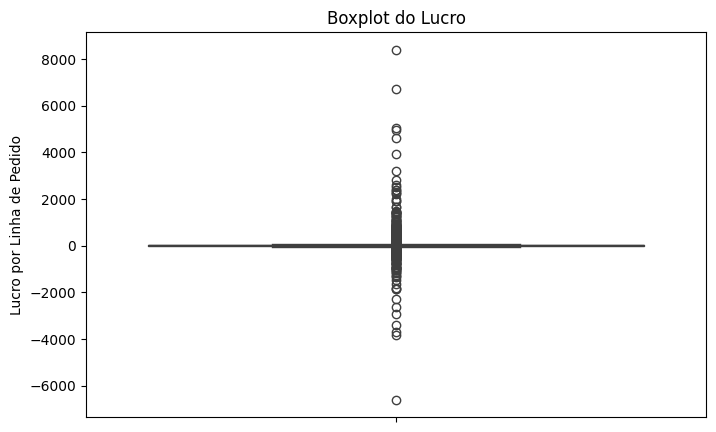

In [203]:
plt.figure(figsize=(8,5))
sns.boxplot(y=dados["lucro"])
plt.title("Boxplot do Lucro")
plt.ylabel("Lucro por Linha de Pedido")
plt.show()

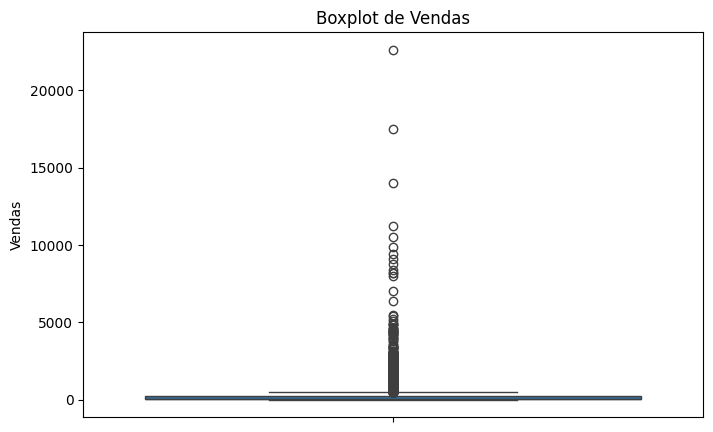

In [204]:
plt.figure(figsize=(8,5))
sns.boxplot(y=dados["vendas"])
plt.title("Boxplot de Vendas")
plt.ylabel("Vendas")
plt.show()

Aqui podemos visualizar alguns outliers como lucros muito grandes ou até prejuizos enormes em relação ao que é  "normal", que pode ser visualizado pelas regiões com mais figuras. Também podemos ver valores de vendas muito altas em relação ao padrão.



---


## 6 - **Validação pós tratamento**:

Informações gerais, tipo dos dados e nome das colunas:

In [205]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_linha         9994 non-null   int64         
 1   id_pedido        9994 non-null   object        
 2   data_pedido      9994 non-null   datetime64[ns]
 3   data_envio       9994 non-null   datetime64[ns]
 4   modo_envio       9994 non-null   object        
 5   id_cliente       9994 non-null   object        
 6   nome_cliente     9994 non-null   object        
 7   segmento         9994 non-null   object        
 8   pais             9994 non-null   object        
 9   cidade           9994 non-null   object        
 10  estado           9994 non-null   object        
 11  cep              9994 non-null   object        
 12  regiao           9994 non-null   object        
 13  id_produto       9994 non-null   object        
 14  categoria        9994 non-null   object 

Estátisticas gerais:

In [206]:
dados.describe()

,id_linha,data_pedido,data_envio,vendas,quantidade,desconto,lucro,ano,mes,dias_para_envio
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,229.858001,3.789574,0.156203,28.656896,2015.722233,7.809686,3.958175
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000,2014.000000,1.000000,0.000000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,17.280000,2.000000,0.000000,1.728750,2015.000000,5.000000,3.000000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,54.490000,3.000000,0.200000,8.666500,2016.000000,9.000000,4.000000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,209.940000,5.000000,0.200000,29.364000,2017.000000,11.000000,5.000000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000,2017.000000,12.000000,7.000000
std,2885.163629,NaN,NaN,623.245101,2.225110,0.206452,234.260108,1.123555,3.284654,1.747567


Tamanho da base de dados:

In [207]:
dados.shape

(9994, 25)

Inicio da base de dados:

In [208]:
dados.head()

,id_linha,id_pedido,data_pedido,data_envio,modo_envio,id_cliente,nome_cliente,segmento,pais,cidade,...,subcategoria,nome_produto,vendas,quantidade,desconto,lucro,ano,mes,ano_mes,dias_para_envio
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,2016-11,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,2016-11,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2016-06,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,2015-10,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,2015-10,7


Decidi não remover os valores iguais a zero e os outliers já que podem ser úteis e  represetar pontos importantes para a empresa.



---


## 7 - **Análise Exploratória:**

In [209]:
total_vendas = dados["vendas"].sum()
total_lucro = dados["lucro"].sum()
quantidade_produtos = dados["quantidade"].sum()
total_pedidos = dados["id_pedido"].nunique()
total_clientes = dados["id_cliente"].nunique()
paises_atingidos = dados["pais"].nunique()
estados_atingidos = dados["estado"].nunique()
ticket_medio = total_vendas / total_pedidos

# Criando uma tabela pra visualização dos dados
tabela = pd.DataFrame({
    "Indicador": [
        "Países atingidos",
        "Estados atingidos",
        "Total de clientes",
        "Total de pedidos",
        "Quantidade total de produtos vendidos",
        "Ticket médio por pedido",
        "Total de vendas",
        "Total de lucro",
    ],
    "Valor": [
        paises_atingidos,
        estados_atingidos,
        total_clientes,
        total_pedidos,
        quantidade_produtos,
        f"$ {ticket_medio:,.2f}",
        f"$ {total_vendas:,.2f}",
        f"$ {total_lucro:,.2f}"
    ]
})

display(tabela)

,Indicador,Valor
0,Países atingidos,1
1,Estados atingidos,49
2,Total de clientes,793
3,Total de pedidos,5009
4,Quantidade total de produtos vendidos,37873
5,Ticket médio por pedido,$ 458.61
6,Total de vendas,"$ 2,297,200.86"
7,Total de lucro,"$ 286,397.02"


Separação de dados importantes para criação de tabelas e insights.

## 7.1 - **Agrupando por categorias:**

In [210]:
categoria = dados.groupby("categoria")[["vendas", "lucro"]].sum().sort_values(by="lucro", ascending=False)
categoria.style.format({
    "vendas": "$ {:,.2f}",
    "lucro": "$ {:,.2f}"
})

,vendas,lucro
categoria,,
Technology,"$ 836,154.03","$ 145,454.95"
Office Supplies,"$ 719,047.03","$ 122,490.80"
Furniture,"$ 741,999.80","$ 18,451.27"


## 7.2 - **Agrupando por subcategorias:**

In [211]:
subcategoria = dados.groupby("subcategoria")[["vendas", "lucro"]].sum().sort_values("lucro", ascending=False)
subcategoria.style.format({
    "vendas": "$ {:,.2f}",
    "lucro": "$ {:,.2f}"
})

,vendas,lucro
subcategoria,,
Copiers,"$ 149,528.03","$ 55,617.82"
Phones,"$ 330,007.05","$ 44,515.73"
Accessories,"$ 167,380.32","$ 41,936.64"
Paper,"$ 78,479.21","$ 34,053.57"
Binders,"$ 203,412.73","$ 30,221.76"
Chairs,"$ 328,449.10","$ 26,590.17"
Storage,"$ 223,843.61","$ 21,278.83"
Appliances,"$ 107,532.16","$ 18,138.01"
Furnishings,"$ 91,705.16","$ 13,059.14"


Separando subcategorias que dão prejuizo:

In [212]:
subcategorias_prejuizo = subcategoria[subcategoria["lucro"] < 0]
subcategorias_prejuizo.style.format({
    "vendas": "$ {:,.2f}",
    "lucro": "$ {:,.2f}"
})

,vendas,lucro
subcategoria,,
Supplies,"$ 46,673.54","$ -1,189.10"
Bookcases,"$ 114,880.00","$ -3,472.56"
Tables,"$ 206,965.53","$ -17,725.48"


## 7.3 - **Agrupamento por segmento:**

In [213]:
segmento = dados.groupby("segmento")[["vendas", "lucro"]].sum().sort_values("vendas", ascending=False)

segmento.style.format({
    "vendas": "$ {:,.2f}",
    "lucro": "$ {:,.2f}"
})

,vendas,lucro
segmento,,
Consumer,"$ 1,161,401.34","$ 134,119.21"
Corporate,"$ 706,146.37","$ 91,979.13"
Home Office,"$ 429,653.15","$ 60,298.68"


Separado por consumidor, empresa/corporativo e home office.

## 7.4 - **Agrupamento por desconto**:

In [214]:
desconto = dados.groupby("desconto")[["vendas", "lucro"]].sum().sort_index()
desconto.style.format({
    "vendas": "$ {:,.2f}",
    "lucro": "$ {:,.2f}"
})

,vendas,lucro
desconto,,
0.000000,"$ 1,087,908.47","$ 320,987.60"
0.100000,"$ 54,369.35","$ 9,029.18"
0.150000,"$ 27,558.52","$ 1,418.99"
0.200000,"$ 764,594.37","$ 90,337.31"
0.300000,"$ 103,226.65","$ -10,369.28"
0.320000,"$ 14,493.46","$ -2,391.14"
0.400000,"$ 116,417.78","$ -23,057.05"
0.450000,"$ 5,484.97","$ -2,493.11"
0.500000,"$ 58,918.54","$ -20,506.43"


## 7.5 - **Agrupamento por lucro medio com descontos**:

In [215]:
lucro_medio_desconto = dados.groupby("desconto")["lucro"].mean().sort_index().reset_index()

lucro_medio_desconto.columns = ["desconto", "lucro_medio"]

lucro_medio_desconto.style.format({
    "desconto": "{:.0%}",
    "lucro_medio": "$ {:,.2f}"
})

,desconto,lucro_medio
0,0%,$ 66.90
1,10%,$ 96.06
2,15%,$ 27.29
3,20%,$ 24.70
4,30%,$ -45.68
5,32%,$ -88.56
6,40%,$ -111.93
7,45%,$ -226.65
8,50%,$ -310.70
9,60%,$ -43.08


## 7.6 - **Agrupamento por vendas e lucro em cada região:**

In [216]:
regiao = dados.groupby("regiao")[["vendas", "lucro"]].sum().sort_values("vendas", ascending=False)
regiao.style.format({
    "vendas": "$ {:,.2f}",
    "lucro": "$ {:,.2f}"
})

,vendas,lucro
regiao,,
West,"$ 725,457.82","$ 108,418.45"
East,"$ 678,781.24","$ 91,522.78"
Central,"$ 501,239.89","$ 39,706.36"
South,"$ 391,721.91","$ 46,749.43"


## 7.7 **Filtrando vendas com prejuizo**:

In [217]:
vendas_com_prejuizo = dados[dados["lucro"] < 0]
vendas_com_prejuizo.head()

,id_linha,id_pedido,data_pedido,data_envio,modo_envio,id_cliente,nome_cliente,segmento,pais,cidade,...,subcategoria,nome_produto,vendas,quantidade,desconto,lucro,ano,mes,ano_mes,dias_para_envio
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,2015-10,7
14,15,US-2015-118983,2015-11-22,2015-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,Appliances,Holmes Replacement Filter for HEPA Air Cleaner...,68.8100,5,0.80,-123.8580,2015,11,2015-11,4
15,16,US-2015-118983,2015-11-22,2015-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,Binders,Storex DuraTech Recycled Plastic Frosted Binders,2.5440,3,0.80,-3.8160,2015,11,2015-11,4
23,24,US-2017-156909,2017-07-16,2017-07-18,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,...,Chairs,"Global Deluxe Stacking Chair, Gray",71.3720,2,0.30,-1.0196,2017,7,2017-07,2
27,28,US-2015-150630,2015-09-17,2015-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7,0.50,-1665.0522,2015,9,2015-09,4


In [218]:
print(f"Quantidade de vendas com prejuizo: {vendas_com_prejuizo.shape[0]}")

Quantidade de vendas com prejuizo: 1871


Importante filtrar e entender qual a ligação e porque esse prejuizo pode estar ocorrendo.

## 7.8 - **Agrupamento por ano e vendas/lucro**:

In [219]:
evolucao_anual = dados.groupby("ano")[["vendas", "lucro"]].sum()
evolucao_anual.style.format({
    "vendas": "$ {:,.2f}",
    "lucro": "$ {:,.2f}"
})


,vendas,lucro
ano,,
2014,"$ 484,247.50","$ 49,543.97"
2015,"$ 470,532.51","$ 61,618.60"
2016,"$ 609,205.60","$ 81,795.17"
2017,"$ 733,215.26","$ 93,439.27"


Util para visualizar a evolução de lucro anual.

## 7.9 - **Observando o prejuizo em vendas com desconto e nas subcategorias**:

In [220]:
total_prejuizo = vendas_com_prejuizo["lucro"].sum()
media_desconto_prejuizo = vendas_com_prejuizo["desconto"].mean()

print(f"Total de prejuízo: $ {total_prejuizo:,.2f}")
print(f"Desconto médio nas vendas com prejuízo: {media_desconto_prejuizo:.2%}")

Total de prejuízo: $ -156,131.29
Desconto médio nas vendas com prejuízo: 48.09%


In [221]:
prejuizo_por_subcategoria = vendas_com_prejuizo.groupby("subcategoria").agg(
    quantidade_registros=("lucro", "count"),
    total_prejuizo=("lucro", "sum"),
    desconto_medio=("desconto", "mean")
).sort_values("total_prejuizo")

prejuizo_por_subcategoria.style.format({
    "total_prejuizo": "$ {:,.2f}",
    "desconto_medio": "{:.2%}"
})

,quantidade_registros,total_prejuizo,desconto_medio
subcategoria,,,
Binders,613,"$ -38,510.50",73.80%
Tables,203,"$ -32,412.15",36.53%
Machines,44,"$ -30,118.67",58.18%
Bookcases,109,"$ -12,152.21",34.85%
Chairs,235,"$ -9,880.84",26.13%
Appliances,67,"$ -8,629.64",80.00%
Phones,136,"$ -7,530.62",34.26%
Furnishings,167,"$ -6,490.91",53.05%
Storage,161,"$ -6,426.30",20.00%




---


## 8 - **VISUALIZAÇÕES GRÁFICAS**:

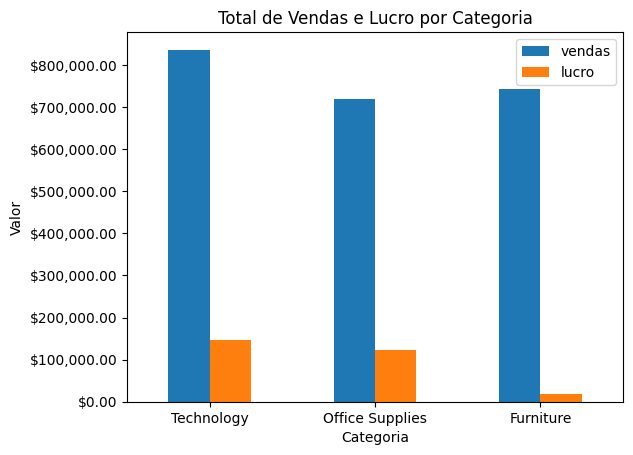

In [222]:
#Função para alterar a formatação do gráfico
def formatar_dinheiro(x, pos):
    return f"${x:,.2f}"

categoria.plot(kind="bar")

plt.title("Total de Vendas e Lucro por Categoria")
plt.xlabel("Categoria")
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(FuncFormatter(formatar_dinheiro))

plt.show()




> Podemos ver no gráfico acima que a categoria de Technology é a que mais tem vendas e lucro, a categoria Furniture tem muitas vendas mas pouco lucro isso pode indicar que problemas estão ocorrendo em relação aos descontos ou precificação de produtos.



> O gráfico mostra que a categoria Office Supplies, mesmo apresentando um volume de vendas menor que Technology e Furniture, possui um lucro relevante. Isso indica que essa categoria pode ter boa rentabilidade e merece atenção estratégica da empresa.



> Esse resultado sugere que Office Supplies pode ser uma oportunidade para maior investimento em campanhas, estoque ou ações comerciais, já que consegue gerar lucro alto mesmo com menor volume de vendas.
---



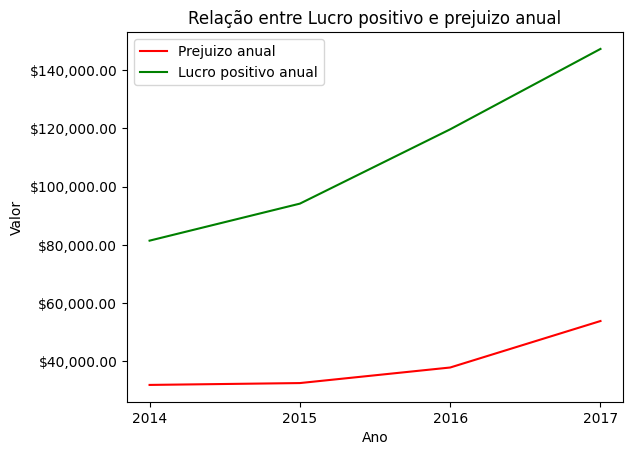

Ano,Valor de vendas,Lucro positivo anual,Prejuizo anual,Lucro líquido anual
2014,"$ 484,247.50","$ 81,436.75","$ 31,892.77","$ 49,543.97"
2015,"$ 470,532.51","$ 94,147.99","$ 32,529.39","$ 61,618.60"
2016,"$ 609,205.60","$ 119,668.10","$ 37,872.93","$ 81,795.17"
2017,"$ 733,215.26","$ 147,275.46","$ 53,836.19","$ 93,439.27"


In [223]:
# Calculando valores anuais
vendas_anual = dados.groupby("ano")["vendas"].sum()
lucro_liquido_anual = dados.groupby("ano")["lucro"].sum()

venda_positiva_anual = dados[dados["lucro"] > 0].groupby("ano")["lucro"].sum()
venda_negativa_anual = dados[dados["lucro"] < 0].groupby("ano")["lucro"].sum().abs()

# Criando tabela anual completa
tabela_valor_anual = pd.DataFrame({
    "Ano": vendas_anual.index,
    "Valor de vendas": vendas_anual.values,
    "Lucro positivo anual": venda_positiva_anual.values,
    "Prejuizo anual": venda_negativa_anual.values,
    "Lucro líquido anual": lucro_liquido_anual.values
})

# Gráfico de vendas que deram lucro e vendas que deram prejuizo
plt.plot(tabela_valor_anual["Ano"], tabela_valor_anual["Prejuizo anual"], label="Prejuizo anual",color="red")
plt.plot(tabela_valor_anual["Ano"], tabela_valor_anual["Lucro positivo anual"], label="Lucro positivo anual",color="green")
plt.title("Relação entre Lucro positivo e prejuizo anual")
plt.xticks(tabela_valor_anual["Ano"])
plt.xlabel("Ano")
plt.ylabel("Valor")
plt.legend()
plt.gca().yaxis.set_major_formatter(FuncFormatter(formatar_dinheiro))

plt.show()

tabela_valor_anual.style.hide(axis="index").format({

    "Valor de vendas": "$ {:,.2f}",
    "Lucro positivo anual": "$ {:,.2f}",
    "Prejuizo anual": "$ {:,.2f}",
    "Lucro líquido anual": "$ {:,.2f}"
})



> No gráfico acima temos a visualização da evolução do lucro positivo e do prejuizo anual em algumas vendas, ambos subiram como consequencia de um maior volume de vendas mas podemos ver que a relação enter lucro positivo e prejuizo anual tem sido cada vez mais distante para o lado positivo, aumentando o lucro líquido anual total.
---



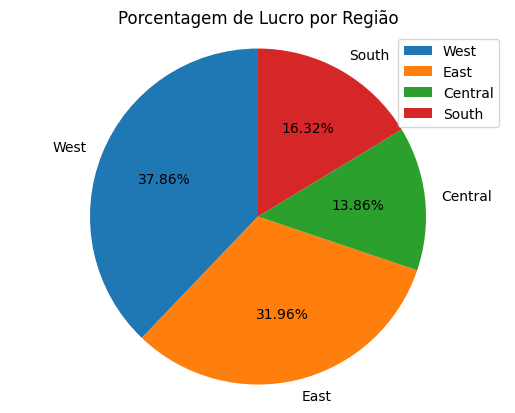

,vendas,lucro
regiao,,
West,"$ 725,457.82","$ 108,418.45"
East,"$ 678,781.24","$ 91,522.78"
Central,"$ 501,239.89","$ 39,706.36"
South,"$ 391,721.91","$ 46,749.43"


In [224]:
# Gráfico de lucro por região
plt.pie(
    regiao["lucro"],
    labels=regiao.index,
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Porcentagem de Lucro por Região")
plt.axis("equal")
plt.legend()
plt.show()
regiao.style.format(
    "$ {:,.2f}"
)



> O gráfico das regiões nos permite entender qual local trás um maior volume de vendas e lucro total para a empresa, o lucro neste gráfico é o lucro total recebido entre os anos de 2014 a 2017 que são os anos apresentados nos dados originais da empresa. Com essa visualização conseguimos entender onde focar em relação a publicidade e marketing dos produtos.
---



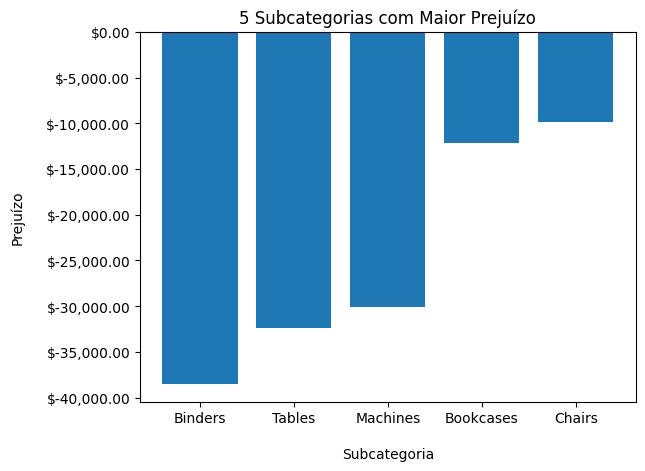

Desconto médio nas vendas com prejuízo: 48.09%


Subcategoria,Registros,Total Prejuízo,Desconto Médio
Binders,613,"$ -38,510.50",73.80%
Tables,203,"$ -32,412.15",36.53%
Machines,44,"$ -30,118.67",58.18%
Bookcases,109,"$ -12,152.21",34.85%
Chairs,235,"$ -9,880.84",26.13%


In [225]:
# Criando top prejuízos para visualização de problemas
top_prejuizo = prejuizo_por_subcategoria.head(5).reset_index()

top_prejuizo = top_prejuizo.rename(columns={
    "subcategoria": "Subcategoria",
    "quantidade_registros": "Registros",
    "total_prejuizo": "Total Prejuízo",
    "desconto_medio": "Desconto Médio"

})
# Gráfico de top prejuízos
plt.bar(
    top_prejuizo["Subcategoria"],
    top_prejuizo["Total Prejuízo"]
)

plt.title("5 Subcategorias com Maior Prejuízo")
plt.xlabel("\nSubcategoria")
plt.ylabel("Prejuízo\n")
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(FuncFormatter(formatar_dinheiro))

plt.show()
print(f"Desconto médio nas vendas com prejuízo: {media_desconto_prejuizo:.2%}")
top_prejuizo.style.hide(axis="index").format(
      {
          "Total Prejuízo": "$ {:,.2f}",
          "Desconto Médio": "{:.2%}"
      }
)





> Entender as subcategorias com maior prejuizo nos ajuda a encontrar problemas tanto no volume de vendas de alguns produtos quanto em relação ao próprio valor deles e o desconto sobre suas vendas, como podemos ver o item com maior prejuizo total é o mesmo com o maior desconto e a média de desconto nas vendas com prejuizo é de 48% de desconto mostrando que talvez o desconto seja uma das causas do prejuizo além do próprio volume de vendas e da precificação dos produtos.



---



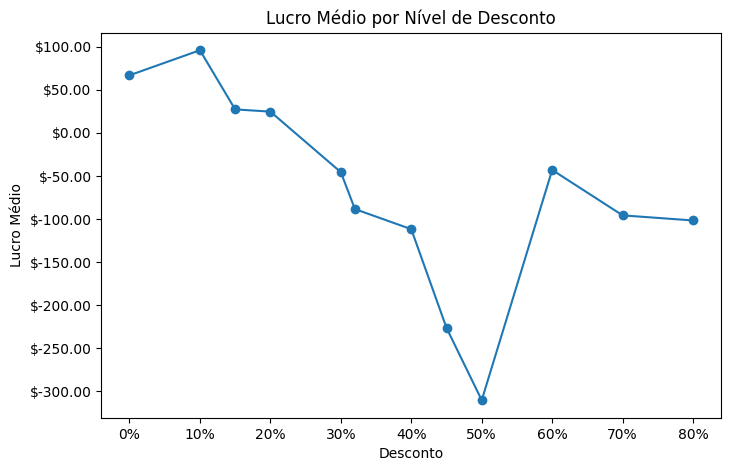

Desconto,Lucro médio
0%,$ 66.90
10%,$ 96.06
15%,$ 27.29
20%,$ 24.70
30%,$ -45.68
32%,$ -88.56
40%,$ -111.93
45%,$ -226.65
50%,$ -310.70
60%,$ -43.08


In [226]:
# Calculando lucro médio por nível de desconto
lucro_medio_desconto = dados.groupby("desconto")["lucro"].mean().sort_index().reset_index()

lucro_medio_desconto.columns = ["Desconto", "Lucro médio"]

# Gráfico de lucro médio por desconto
plt.figure(figsize=(8,5))

plt.plot(
    lucro_medio_desconto["Desconto"],
    lucro_medio_desconto["Lucro médio"],
    marker="o"
)

plt.title("Lucro Médio por Nível de Desconto")
plt.xlabel("Desconto")
plt.ylabel("Lucro Médio")
plt.gca().yaxis.set_major_formatter(FuncFormatter(formatar_dinheiro))
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))

plt.show()

lucro_medio_desconto.style.hide(axis="index").format({
    "Desconto": "{:.0%}",
    "Lucro médio": "$ {:,.2f}"
})



> Nesse gráfico é possivel observar melhor a relação entre desconto e lucro médio. Os descontos de 0% e 10% ainda apresentam lucro médio positivo, mas a partir de 30% o lucro médio passa a ficar negativo. As maiores perdas aparecem principalmente nas faixas de 45% e 50% de desconto, com destaque também para descontos altos, como 70% e 80%. Isso mostra que descontos maiores podem estar ligados à queda do lucro e, em alguns casos, ao prejuízo nas vendas.



> Isso indica que a empresa precisa ter mais cuidado com a política de descontos, porque vender com desconto alto nem sempre significa vender melhor. Em alguns casos, o desconto pode estar reduzindo ou até eliminando o lucro total.

---

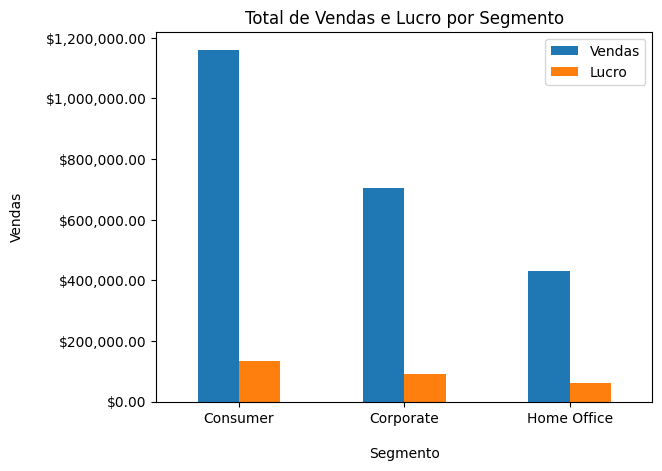

Segmento,Vendas,Lucro
Consumer,"$ 1,161,401.34","$ 134,119.21"
Corporate,"$ 706,146.37","$ 91,979.13"
Home Office,"$ 429,653.15","$ 60,298.68"


In [227]:
# Gráfico de vendas por segmento
tabela_segmento = pd.DataFrame({
    "Segmento": segmento.index,
    "Vendas": segmento["vendas"],
    "Lucro": segmento["lucro"]
})

tabela_segmento.plot(kind="bar")

plt.title("Total de Vendas e Lucro por Segmento")
plt.xlabel("\nSegmento")
plt.ylabel("Vendas\n")
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(FuncFormatter(formatar_dinheiro))

plt.show()

tabela_segmento.style.hide(axis="index").format({
    "Vendas": "$ {:,.2f}",
    "Lucro": "$ {:,.2f}"
})



> Agora que ja abordamos os produtos que tem um retorno negativo, a evolução anual do lucro e as regiões com maior venda, podemos observar em qual segmento o volume de vendas é maior e entender como isso está relacionado com o lucro dos produtos. Nesse gráfico acima podemos visualizar que o segmento com maior número de vendas e lucro é o Consumer, mostrando sua relevância para a empresa.


---



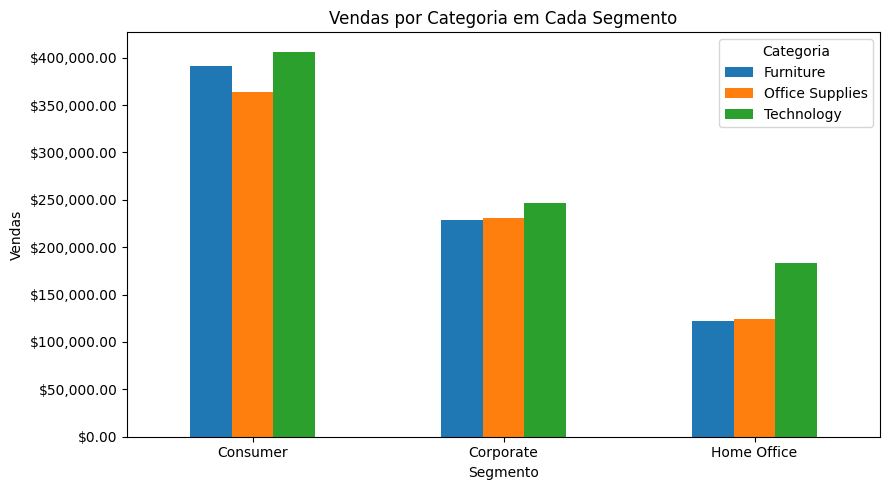

categoria,Furniture,Office Supplies,Technology
segmento,,,
Consumer,"$ 391,049.31","$ 363,952.14","$ 406,399.90"
Corporate,"$ 229,019.79","$ 230,676.46","$ 246,450.12"
Home Office,"$ 121,930.70","$ 124,418.43","$ 183,304.02"


In [228]:
# Agrupando vendas por segmento e categoria
vendas_segmento_categoria = dados.groupby(["segmento", "categoria"])["vendas"].sum().reset_index()

# Transformando em tabela para o gráfico
tabela_segmento_categoria = vendas_segmento_categoria.pivot(
    index="segmento",
    columns="categoria",
    values="vendas"
).fillna(0)

# Criando o gráfico
ax = tabela_segmento_categoria.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Vendas por Categoria em Cada Segmento")
plt.xlabel("Segmento")
plt.ylabel("Vendas")
plt.xticks(rotation=0)
plt.legend(title="Categoria")
plt.gca().yaxis.set_major_formatter(FuncFormatter(formatar_dinheiro))
plt.tight_layout()

plt.show()

# Mostrando a tabela formatada
tabela_segmento_categoria.style.format("$ {:,.2f}")



> No gráfico acima é possivel ver que a categoria Technology vende mais dentro dos três segmentos analisados: Consumer, Corporate e Home Office. Mesmo que em alguns segmentos a diferença para as outras categorias não seja tão grande, ela aparece como a categoria com melhor desempenho em todos eles. Isso ajuda a entender por que, na análise geral por categoria, Technology aparece com o maior volume de vendas. Mostrando que esse resultado vem de um volume de vendas maior e mais consistente.

---



## 9 - **Conclusão**:

A análise mostrou que a empresa possui lucro líquido positivo ao longo dos anos, mesmo existindo vendas com prejuízo. A categoria Technology aparece como a principal em vendas e lucro, enquanto Furniture apresenta muitas vendas, mas pouco lucro, indicando possível problema de rentabilidade.

Também foi possível observar que descontos mais altos estão ligados à queda do lucro médio, principalmente a partir de 30%. Algumas subcategorias, como Binders, Tables e Machines, concentram os maiores prejuízos, o que mostra que esses produtos precisam de mais atenção.

O segmento Consumer foi o que apresentou maior volume de vendas e lucro, mostrando sua importância para o faturamento da empresa. Além disso, Technology teve bom desempenho em todos os segmentos, o que explica seu destaque na análise geral.
As regiões com maior lucro foram West e East, indicando também regiões onde o investimento pode render um lucro ainda maior.

Com isso, a análise ajuda a entender melhor onde a empresa vende mais, onde lucra mais e onde pode estar perdendo dinheiro.